In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('dataset/exam_mark_placement.csv')

In [21]:
df.sample()

,cgpa,placement_exam_marks,placed
361,6.37,37,1


In [22]:
df.shape

(1000, 3)

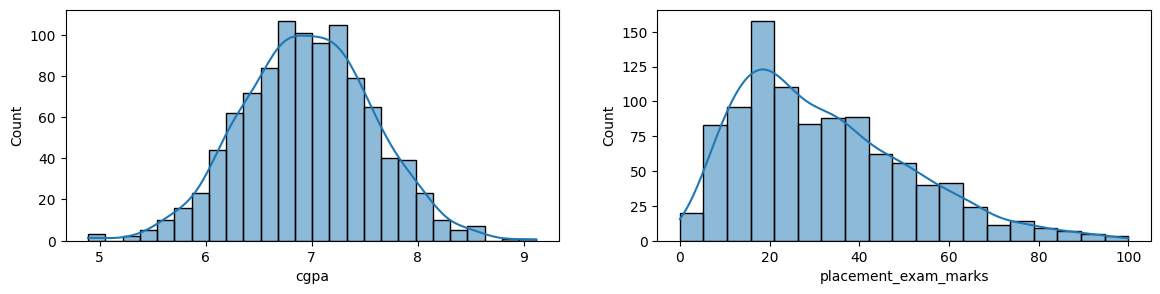

In [23]:
plt.figure(figsize=(14,3))
plt.subplot(1,2,1)
sns.histplot(df.cgpa, kde=True)

plt.subplot(1,2,2)
sns.histplot(df.placement_exam_marks,kde=True)

plt.show()

In [24]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [25]:
df.placement_exam_marks.describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

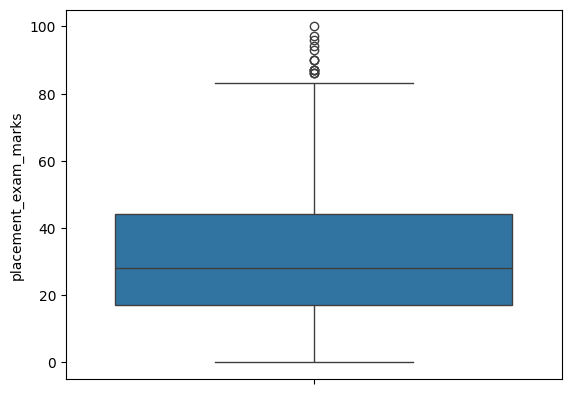

In [26]:
sns.boxplot(df.placement_exam_marks)
plt.show()

In [27]:
#finding iqr
percentile75 =df.placement_exam_marks.quantile(0.75)
percentile25 =df.placement_exam_marks.quantile(0.25)
iqr = percentile75 - percentile25 
iqr

np.float64(27.0)

In [28]:
percentile75

np.float64(44.0)

In [29]:
upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr
print(upper_limit)
print(lower_limit)

84.5
-23.5


### Trimming

In [30]:
new_df = df[(df.placement_exam_marks > lower_limit) & (df.placement_exam_marks < upper_limit)]
new_df.sample()

,cgpa,placement_exam_marks,placed
611,7.2,19,1


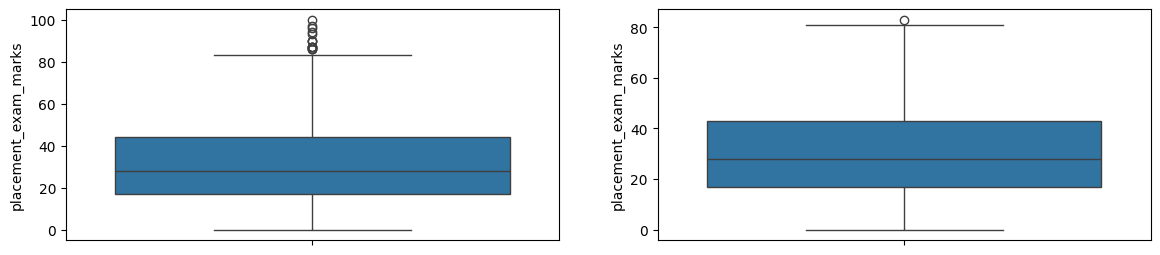

In [31]:
plt.figure(figsize=(14,3))
plt.subplot(1,2,1)
sns.boxplot(df.placement_exam_marks)

plt.subplot(1,2,2)
sns.boxplot(new_df.placement_exam_marks)

plt.show()

In [32]:
new_df.shape

(985, 3)

## Percentile Method

In [34]:
df = pd.read_csv('dataset/weight-height.csv')
df.sample()

,Gender,Height,Weight
7586,Female,56.737183,91.605437


In [35]:
df.shape

(10000, 3)

In [39]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

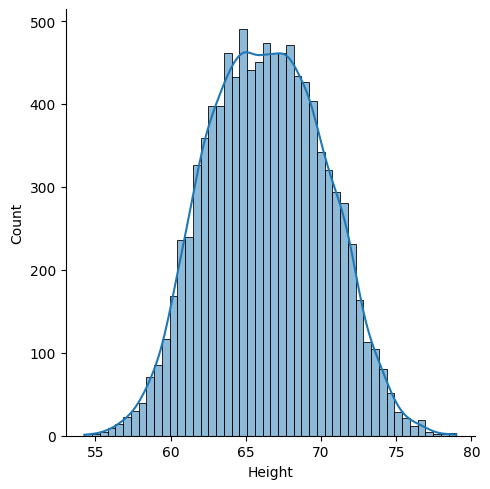

In [41]:
sns.displot(df.Height, kde=True)

<Axes: ylabel='Height'>

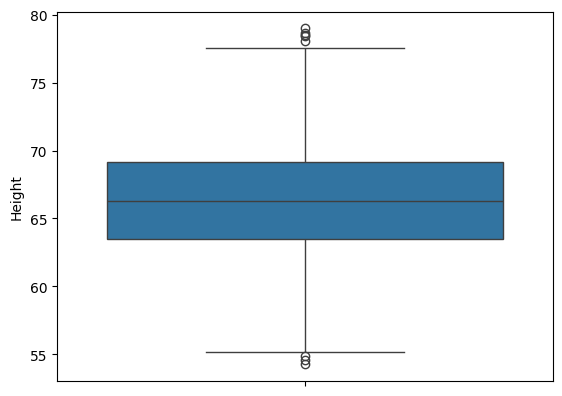

In [42]:
sns.boxplot(df.Height)

In [52]:
#Trimming
#making upper and lower limit
upper_limit = df['Height'].quantile(0.99)
lower_limit=df['Height'].quantile(0.01)

In [53]:
print(upper_limit, lower_limit)

74.7857900583366 58.13441158671655


In [54]:
new_df =df[(df.Height > lower_limit) & (df.Height< upper_limit)]
new_df.sample(5)

,Gender,Height,Weight
7421,Female,66.499867,143.758007
2357,Male,71.980009,191.016162
1819,Male,72.337569,216.713478
1717,Male,69.338298,198.389549
7072,Female,64.650818,135.033626


In [55]:
new_df.shape

(9800, 3)

<Axes: xlabel='Height', ylabel='Count'>

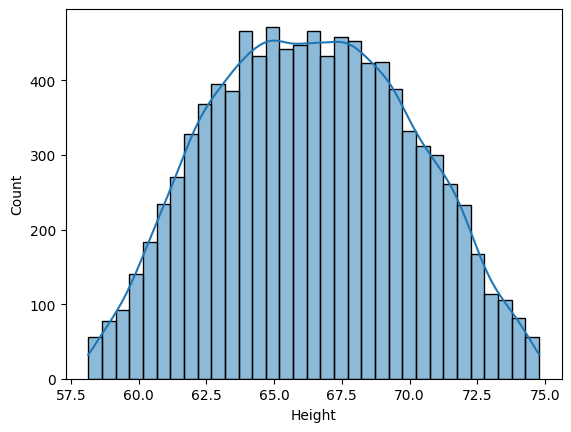

In [56]:
sns.histplot(new_df.Height, kde=True)

In [57]:
new_df.Height.describe()

count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64

In [58]:
df.Height.describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: ylabel='Height'>

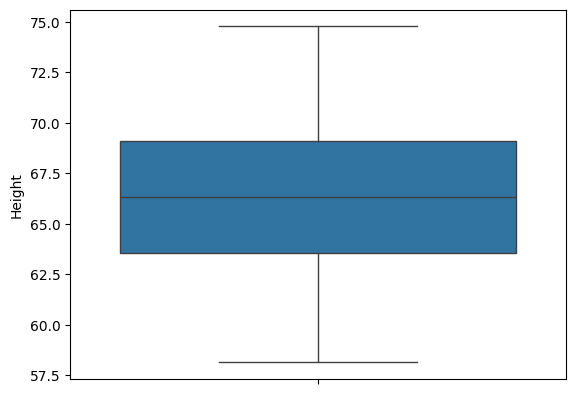

In [59]:
sns.boxplot(new_df.Height)

###  Capping / Winsorization

In [62]:
df.Height = np.where(df.Height >= upper_limit,
        upper_limit,
        np.where(df.Height<=lower_limit,
        lower_limit,
        df.Height
        ))

In [64]:
df.shape

(10000, 3)

In [65]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.366281,161.440357
std,3.795717,32.108439
min,58.134412,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,74.785790,269.989699


<Axes: ylabel='Height'>

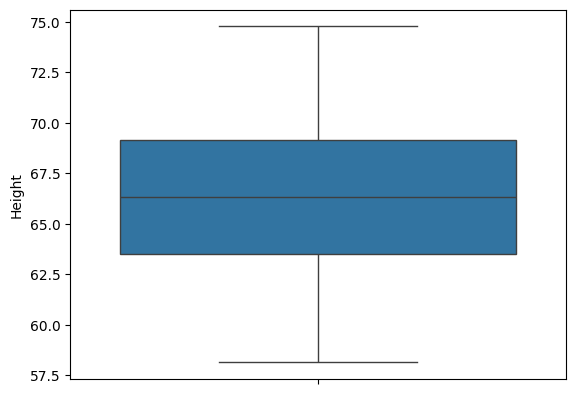

In [66]:
sns.boxplot(df.Height)

<Axes: xlabel='Height', ylabel='Count'>

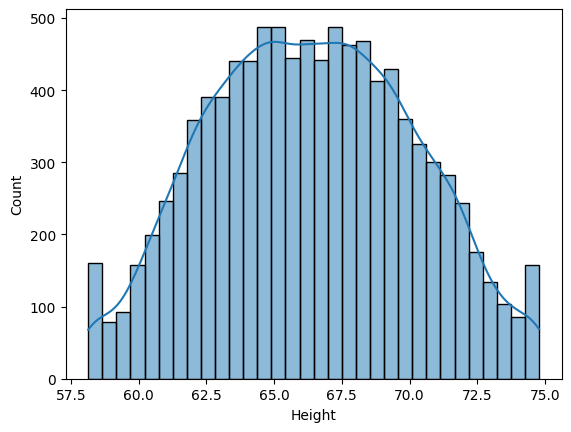

In [68]:
sns.histplot(df.Height, kde= True)